In [1]:
%load_ext autoreload
%autoreload 2
import os
import functools
from pathlib import Path
import numpy as np

import re
import matplotlib.pyplot as plt

imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())


os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False

dataset_location = "./data/clevr-real-block-v3"
dataset_location = Path(dataset_location)

model_location = Path("./data/models/")
model_path = model_location / "clevr-act-7-depth_text_aug" / "checkpoint-4687"

save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

if "depth_depth_l40" in str(model_path):
    return_depth = True

print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

dataset_location data/clevr-real-block-v3
moadel_path is data/models/clevr-act-7-depth_text_aug/checkpoint-4687


dataset len 160
160


  0%|          | 0/3 [00:00<?, ?it/s]


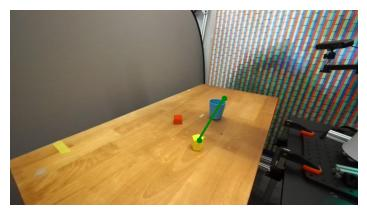
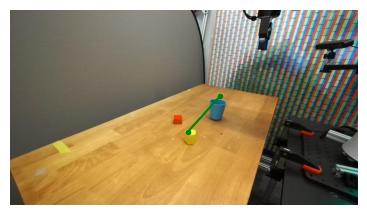
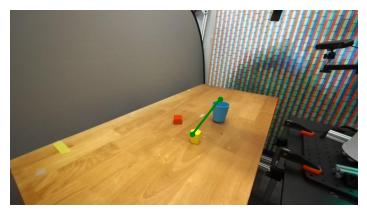

In [2]:
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter


test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example

def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
print(len(test_dataset))
num_samples = 3
html_imgs = ""
for i in tqdm(range(num_samples)):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"])
    
display(HTML(html_imgs))

In [3]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

DEVICE = 'cuda' # torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        padding="longest"
    ).to(TORCH_DTYPE).to(DEVICE)
    return inputs

Using device: cuda
loaded processor.


## Evaluate beams

In [27]:
save_folder = "data/beam3_original/"
#save_folder = "data/beam_std_original/"
crop_size = 1300
episode_i = 0

with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
    sequences = np.load(f)
    scores = np.load(f)
    sequence_scores = np.load(f)

# prefix (text label and robot pos) + suffix (start pos and end pos)
decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
print(decoded_str)

# (n_beams, encoded_steps)
print(sequences.shape)

# (steps, n_beams, n_tokens)
print(scores.shape)

# n_beams
print(sequence_scores.shape)

<loc0731><loc0150><loc0042><seg046><seg053><seg038><loc0464><loc0606><loc0044><seg046><seg053><seg038>
(3, 285)
(12, 3, 1024)
(3,)


In [28]:
# load all episodes and beams
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)
test_samples = len(test_dataset)
sample_list = list(range(test_samples))

pred_list = []
score_list = [] # [i] = np.ndarray(n_beams, steps)
beam_list = [] # [i] = [beam1_str, beam2_str ...]
print_samples = 2
for episode_i in sample_list:
    if episode_i < print_samples:
        print("==== episode", episode_i)
    
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        sequences = np.load(f)
        scores = np.load(f)
        sequence_scores = np.load(f)
    decoded_str = processor.decode(sequences[0], skip_special_tokens=True).split('\n')[1]
    
    pred_list.append(decoded_str)
    score_list.append(sequence_scores)

    beams = []
    for i in range(3):
        # prefix\nsuffix
        suffix = processor.decode(sequences[i], skip_special_tokens=True).split('\n')[1]
        beams.append(suffix)
        if episode_i < print_samples:
            print(suffix, sequence_scores[i])
        
    beam_list.append(beams)


==== episode 0
<loc0731><loc0150><loc0042><seg046><seg053><seg038><loc0464><loc0606><loc0044><seg046><seg053><seg038> -1.6372637
<loc0491><loc0611><loc0049><seg052><seg060><seg030><loc0460><loc0606><loc0044><seg052><seg060><seg030> -1.9965687
<loc0731><loc0150><loc0042><seg046><seg053><seg038><loc0464><loc0606><loc0490><loc0047><seg046><seg053> -2.4160843
==== episode 1
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0443><loc0606><loc0062><seg055><seg036><seg018> -1.8307576
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc0244><loc0882><loc0078><seg055><seg036><seg018> -1.8772146
<loc0728><loc0144><loc0050><seg055><seg036><seg018><loc1023><loc1023><loc0033><seg055><seg036><seg018> -2.0936244


In [29]:
# evaluate all episodes and beams
import re

# Max Argus evaluation
results = []
beam_scores = []
beam_errors = []
best_beams = []
for i, pred in enumerate(pred_list):
    # ground truth
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", suffix)])
    decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)])
    
    if len(suffix_p) != 12 or len(decode_p) != 12:
        continue

    # maniskill coors -> image coors
    image = test_dataset[i][0]
    h, w = image.size
    suffix_p[[0, 6]] *= h/1024
    suffix_p[[1, 7]] *= w/1024
    decode_p[[0, 6]] *= h/1024
    decode_p[[1, 7]] *= w/1024

    # === find beam with minimum error (oracle)
    error = []
    for beam_i in range(3):
        decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", pred)])
        decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][beam_i])])
        decode_p[[0, 6]] *= h/1024
        decode_p[[1, 7]] *= w/1024
        #print(decode_p)

        pred_diff = np.mean(np.abs(np.array(suffix_p) - np.array(decode_p)))
        error.append(pred_diff)
        beam_errors.append(pred_diff)
        beam_scores.append(score_list[i][beam_i])
    best = np.argmin(error)
    best_beams.append(best)
    decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][best])])
    decode_p[[0, 6]] *= h/1024
    decode_p[[1, 7]] *= w/1024

    
    # === the most likely beam. sequence_scores are sorted by decreasing order
    most_likely = True # CHANGE ME
    if most_likely:
        decode_p = np.array([float(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", beam_list[i][0])])
        decode_p[[0, 6]] *= h/1024
        decode_p[[1, 7]] *= w/1024


    
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

#results[:, 0:2] = results[:, 0:2]/1024*224 
#results[:, 6:8] = results[:, 6:8]/1024*224 

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()

Valid Samples: 160 L1: 33.42294921875



Beam search-NMS Spearman Rank Coefficient: 0.49
saving to:  beam_search-nms.pdf


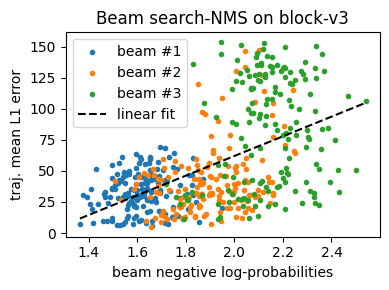

In [30]:
import numpy as np
from scipy import stats

if save_folder == "data/beam3_original/":
    method_name = "Beam search-NMS"
elif save_folder == "data/beam_std_original/":
    method_name = "Beam search"
else:
    raise ValueError

beam_scores = np.array(beam_scores)
beam_errors = np.array(beam_errors)

res = stats.spearmanr(-beam_scores, beam_errors)
res.statistic
print(f"{method_name} Spearman Rank Coefficient: {res.statistic:0.02f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(-np.array(beam_scores[0::3]), beam_errors[0::3], marker='.', label="beam #1")
ax.scatter(-np.array(beam_scores[1::3]), beam_errors[1::3], marker='.', label="beam #2")
ax.scatter(-np.array(beam_scores[2::3]), beam_errors[2::3], marker='.', label="beam #3")
#ax.set_xlim(0, 1024)

    
ax.set_title(f"{method_name} on block-v3")
ax.set_ylabel("traj. mean L1 error")
ax.set_xlabel("beam negative log-probabilities")

coef = np.polyfit(beam_scores,beam_errors, 1)
poly1d_fn = np.poly1d(coef)

x_range = np.linspace(min(-beam_scores), max(-beam_scores), 10)
ax.plot(x_range, poly1d_fn(-x_range), '--k', label='linear fit')

ax.legend()
fig.tight_layout()

fn = f"{method_name.lower().replace(' ','_')}.pdf"
print("saving to: ", fn)
plt.savefig(fn)
plt.show()

Text(0.5, 1.0, 'Index of best beam')

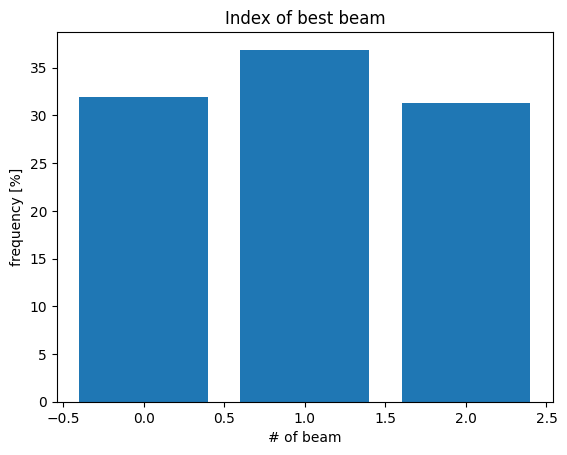

In [26]:
fig, ax = plt.subplots()

ax.bar([0, 1, 2], np.array([best_beams.count(0), best_beams.count(1), best_beams.count(2)])/len(best_beams)*100)
#ax.set_xlim(0, 1024)
ax.set_ylabel("frequency [%]")
ax.set_xlabel("# of beam")
ax.set_title("Index of best beam")

## Object detection style

In [44]:
save_folder = "data/beam3_original/"
#save_folder = "data/beam_std_original/"
crop_size = 1300
episode_i = 0

# load all episodes and beams
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    return_depth=return_depth
)

In [45]:
def intersection_over_union(image, t1, t2):
    """
    image: PIL image
    t1: 1D array of size 12
    t2: 1D array of size 12
    trajectory format: obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)

    return: float
    """
    
    h, w = image.size
    diff = t1.reshape((2, 6))[:, :2] - t2.reshape((2, 6))[:, :2]
    error = np.mean(np.abs(diff))
    max_error = (h + w) / 2
    return error / max_error

image, sample = test_dataset[i] # image size 1280 x 720
t1 = np.array([0, 0,   0, 0, 0, 0,  720, 1280,  0, 0, 0, 0])
t2 = np.array([720, 1280,   0, 0, 0, 0,  0, 0,  0, 0, 0, 0])
assert intersection_over_union(image, t1, t2) == 1.0

In [ ]:
from collections import Counter

import torch
from IoU import intersection_over_union

def intersection_over_union(image, t1, t2):
    # trajectory format:
    # suffix (12) = obj_start (h w d rv0 rv1 rv2), obj_end (h w d rv0 rv1 rv2)
    h, w = image.size
    diff = t1.reshape((2, 6))[:, :2] - t2.reshape((2, 6))[:, :2]
    error = np.mean(np.abs(diff))
    max_error = (h + w) / 2
    return error / max_error
    

def mean_average_precision(
    predictions,
    true_boxes,
    iou_thresh=.5,
    box_format='corners',
    num_classes=20
):
    average_precision = []
    epsilon = 1e-6

    # Predictions: [[train_idx, class, probability, x1, y1, x2, y2], ...]
    for c in range(num_classes):
        detections = []
        ground_truths = []

        for pred in predictions:
            if pred[1] == c:
                detections.append(pred)

        for true_box in true_boxes:
            if true_box[1] == c:
                ground_truths.append(true_box)

        # img 0 has 3 bboxes
        # img 1 has 5 bboxes
        # amount_bboxes = {0: 3, 1: 5}
        amount_bboxes = Counter([
            gt[0]
            for gt in ground_truths
        ])

        for key, val in amount_bboxes.items():
            amount_bboxes[key] = torch.zeros(val)

        # After this loop:
        # amount_bboxes = {
        #     0: torch.tensor([0, 0, 0]),
        #     1: torch.tensor([0, 0, 0, 0, 0])
        # }

        detections = detections.sort(key=lambda x: x[2], reverse=True)
        TP = torch.zeros(len(detections))
        FP = torch.zeros(len(detections))
        total_true_bboxes = len(ground_truths)

        for detection_idx, detection in enumerate(detections):
            ground_truth_img = [
                bbox
                for bbox in ground_truths
                if bbox[0] == detection[0]
            ]
            best_iou = 0
            best_gt_idx = None

            for idx, gt in enumerate(ground_truth_img):
                iou = intersection_over_union(
                    torch.tensor(detection[3:]),  # x1, y1, x2, y2
                    torch.tensor(gt[3:]),  # x1, y1, x2, y2
                    box_format=box_format
                )

                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = idx
            
            if best_iou > iou_thresh:
                if amount_bboxes[detection[0]][best_gt_idx] == 0:
                    TP[detection_idx] = 1
                    amount_bboxes[detection[0]][best_gt_idx] = 1
                else:
                    FP[detection_idx] = 1
            
            else:
                FP[detection_idx] = 1
        
        # [1, 1, 0, 1, 0] -> [1, 2, 2, 3, 3]
        TP_cum_sum = torch.cumsum(TP, dim=0)
        FP_cum_sum = torch.cumsum(FP, dim=0)

        recalls = TP_cum_sum / (total_true_bboxes + epsilon)
        precisions = TP_cum_sum / (TP_cum_sum + FP_cum_sum + epsilon)
        
        recalls = torch.concat((
            torch.tensor([0]),
            recalls
        ))
        precisions = torch.concat((
            torch.tensor([1]),
            precisions
        ))

        average_precision.append(torch.trapz(  # To calculate the area
            precisions,  # Y values
            recalls  # X values
        ))
    
    return sum(average_precision) / len(average_precision)